TAREA: EXPLORANDO TRANSFORMERS EN TEXTO, AUDIO Y VISIÓN

**Nombre del alumno:** Roberto Carlos Santos Alonzo

**Matrícula:**

**Fecha:** 20-05-2026

OBJETIVO:

Aplicar conceptos vistos en clase sobre Transformers mediante tres casos:

1. Texto con BERT/BETO.
2. Audio con Whisper.
3. Imagen con un mini Vision Transformer.

INSTRUCCIONES:

- Completa las celdas marcadas como ACTIVIDAD.
- Explica tus resultados en las celdas de reflexión.
- No basta con ejecutar código: debes interpretar lo que ocurre.
- Comenta cualquier modificación que hagas:

 **Nota:** En toda parte del código, pondré comentarios para mayor entendimiento de lo que hace cada linea, ayudado de la IA gemini


FECHA DE ENTREGA:
20 de Mayo del año en curso

# CELDA 1: INSTALACIÓN

**Añado comentarios de las librerías**

In [1]:
# ==============================================================================
# CONFIGURACIÓN DEL ENTORNO PARA MODELOS DE AUDIO Y NLP (AI ARCHITECTURE)
# ==============================================================================

# Instala la librería core de Hugging Face. Da acceso a miles de modelos preentrenados
# (Transformers) para tareas de audio como Whisper (STT) o Wav2Vec2.
# El flag '-q' (quiet) mantiene la consola limpia reduciendo el output de la instalación.
!pip install -q transformers

# Instala la herramienta optimizada para la descarga, manejo y streaming de
# conjuntos de datos masivos (datasets de audio/texto), gestionando eficientemente la memoria.
!pip install -q datasets

# Instala la librería estándar de la industria para el análisis y procesamiento de audio.
# Es fundamental para tareas de DSP (Digital Signal Processing), como extraer features o cambiar sample rates.
!pip install -q librosa

# Instala una biblioteca de alta confianza para leer y escribir archivos de audio
# en múltiples formatos (WAV, FLAC, OGG), interactuando directamente conlibs nativas (libsndfile).
!pip install -q soundfile

# Instala el motor de optimización de Hugging Face. Permite pasar el modelo a producción
# de forma eficiente, facilitando el entrenamiento y la inferencia distribuidos (Multi-GPU/TPU)
# y la carga de modelos en precisión reducida (8-bit o 4-bit) para ahorrar VRAM.
!pip install -q accelerate

# CELDA 2: IMPORTS GENERALES

In [2]:
# ==============================================================================
# IMPORTACIÓN DE LIBRERÍAS Y CONFIGURACIÓN DE HARDWARE (AI ARCHITECTURE)
# ==============================================================================

# --- 1. CIENCIA DE DATOS Y VISUALIZACIÓN CORE ---
import numpy as np       # Manipulación eficiente de matrices y tensores numéricos.
import pandas as pd      # Gestión de estructuras de datos tabulares (metadata de audio, etiquetas).
import matplotlib.pyplot as plt  # Creación de gráficos (pistas de audio, curvas de pérdida).

# --- 2. PROCESAMIENTO Y VISUALIZACIÓN DE AUDIO ---
import librosa           # Extracción de características de audio (MFCCs, espectrogramas).
import librosa.display   # Funciones específicas para graficar ondas de audio y espectrogramas.

# --- 3. INTERFAZ DE USUARIO Y ENTORNO (JUPYTER/COLAB) ---
from IPython.display import Audio, display  # Permite reproducir audio directamente en las celdas del notebook.
from google.colab import files              # Utilidad exclusiva de Google Colab para subir/descargar archivos localmente.

# --- 4. ECOSISTEMA PYTORCH & HUGGING FACE (AUDIO & NLP) ---
import torch             # Framework principal de Deep Learning para los modelos de Hugging Face.
from transformers import AutoTokenizer           # Tokenizador automático para modelos de lenguaje basados en texto.
from transformers import AutoModelForMaskedLM    # Modelo para tareas de procesamiento de lenguaje natural (ej. BERT).
from transformers import WhisperProcessor        # Preprocesador específico para Whisper (convierte audio a features que el modelo entiende).
from transformers import WhisperForConditionalGeneration  # El modelo secuencia a secuencia Whisper para transcripción de audio (STT).

# --- 5. ECOSISTEMA TENSORFLOW & KERAS (ARQUITECTURAS CUSTOM) ---
import tensorflow as tf
from tensorflow.keras.datasets import mnist  # Dataset clásico de dígitos escritos a mano (procesamiento de imágenes).
# Componentes para construir una arquitectura Transformer personalizada en Keras:
from tensorflow.keras.layers import (
    Input,                  # Capa de entrada que define la forma de los datos (shape).
    Dense,                  # Capa densa / completamente conectada (lineal).
    Dropout,                # Técnica de regularización para evitar el sobreentrenamiento (overfitting).
    LayerNormalization,     # Normalización por capa, crítica para la estabilidad de Transformers.
    MultiHeadAttention,     # El núcleo de la arquitectura Transformer (Mecanismo de Atención Multi-Cabeza).
    GlobalAveragePooling1D  # Reducción de dimensionalidad promediando secuencias temporales.
)
from tensorflow.keras.models import Model      # API Funcional de Keras para instanciar la arquitectura del modelo.
from tensorflow.keras.optimizers import Adam   # Optimizador estándar para actualizar los pesos del modelo.

# --- 6. GESTIÓN DE RECURSOS DE HARDWARE (ORQUESTACIÓN) ---
# Detecta si hay una GPU disponible (CUDA) y asigna el dispositivo de ejecución en consecuencia.
# Esto asegura que el código de PyTorch corra en GPU si está disponible, o en CPU si no.
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Dispositivo:", device)

Dispositivo: cuda


# PREGUNTAS CONCEPTUALES

Responde con tus propias palabras

## PREGUNTA 1

**¿Qué problema resolvió Transformer respecto a RNN, LSTM y GRU?**

Respuesta:

RNN, LSTM Y GRU tienen el problema de la secuencialidad, el estado presente depende del estado anterior ($h_t$ depende de $h_{t-1}$). Como se explicó en clase, es como si estuvieramos en una autopista y solo tuvieramos disponible un carril, por más rápido que sean los carros, todos están obligados a avanzar uno detrás de otro en una fila.

El transformer llega a resolver este tema con el procesamiento paralelo, es como si estuvieramos en la misma pista, solo que en está tendríamos múltiples carriles.

## PREGUNTA 2

**Explica la fórmula de <code> self-attention </code>:**

$$
Attention(Q,K,V)=softmax\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

**Incluye qué representan Q, K y V.**

Respuesta:

<code> self - attention </code> calcula la importancia (atención) que debe darle una palabra a cada una de las demás dentro de una frase.

- **Q (query):**  Representa la palabra actual que se está analizando (pregunta).

- **K (Key):** Representa todas las palabras de la secuencia de entrada (etiquetas).

- **V (Value):**  Representa el contenido real


## PREGUNTA 3

Explica la diferencia entre:

- **encoder-only:** El objetivo principal es **entender el contexto** de las palabras. **NO** están diseñados para generar texto.

  Un ejemplo de este modelo sería el uso dentro de mi trabajo actual **La comer**, para ver el análisis de las opiniones que los clientes dejan en la página web sobre la calidad del servicio.  Podríamos automatizar la clasificación de estos comentarios (servicio de entrega, calidad de los productos, atención al cliente, etc).

- **decoder-only:** Este modelo está diseñado para **predecir la siguiete palabra** en una secuencia.  Sirven para generación de contenido.

  Volviendo a un ejemplo en la comer, se podría realizar un Chatbot de atención al cliente para poder responder "quejas" de manera rápida y eficiente.

- **encoder-decoder:** Este modelo sirve para entender el contexto, procesarlo por completo y transformarlo en una secuencia de salida totalmente nueva.
  
  Un caso de aplicación en la comer, sería un **resumen automático de quejas**, hay comentarios muy largos, donde casi casi escriben una historia, para este caso nos convendría utilizar este modelo para tener un resumen de la queja.


# PARTE 2

**TOKENIZACIÓN Y BERT/BETO**

En esta sección analizarás cómo un modelo tipo BERT convierte texto en tokens numéricos.

**Añado comentarios**



In [3]:
# --- CONFIGURACIÓN DEL MODELO SELECCIONADO ---
# Definimos el identificador del modelo en el Hub de Hugging Face.
# "dccuchile/bert-base-spanish-wwm-cased" corresponde a BETO, una versión de BERT
# entrenada específicamente para el idioma español por el DCC de la Universidad de Chile.
# - "wwm": Whole Word Masking (enmascaramiento de palabras completas durante el preentrenamiento).
# - "cased": Mantiene la distinción entre mayúsculas y minúsculas (crucial para NER y sintaxis).
modelo_bert = "dccuchile/bert-base-spanish-wwm-cased"

# --- INICIALIZACIÓN DEL ARTIFACT (TOKENIZADOR) ---
# AutoTokenizer es un patrón de diseño "Factory". Detecta automáticamente la arquitectura
# del modelo configurada en los metadatos del repositorio (en este caso, BERT) e instancía
# la clase correspondiente (BertTokenizerFast) junto con su vocabulario específico.
tokenizer_bert = AutoTokenizer.from_pretrained(modelo_bert)

# --- VERIFICACIÓN DE CARGA ---
# Confirmamos que el pipeline de preprocesamiento ha cargado correctamente los archivos
# 'vocab.txt' y la configuración del tokenizador en la memoria RAM del sistema.
print("Tokenizer cargado:", modelo_bert)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

Tokenizer cargado: dccuchile/bert-base-spanish-wwm-cased


## ACTIVIDAD 1

**Añado comentarios y partes de código**

Tokenizar frases

Instrucciones:

1. Escribe $10$ frases en español.
2. Tokeniza cada frase.
3. Muestra:
    - Frase original.
    - tokens.
    - input_ids
    - attention_mask


In [4]:
# --- CONJUNTO DE DATOS DE ENTRADA (CORPUS DE PRUEBA) ---
# Definimos las secuencias de texto que se inyectarán en el pipeline.
# Como BETO/BERT procesa a nivel de lote (batch), estas listas se convertirán en tensores.
frases = [
    "La inteligencia artificial está cambiando la educación.",
    "Los modelos Transformer procesan secuencias mediante atención.",
    "Las redes neuronales convolucionales destacan en la clasificación de imágenes" # 1,
    "Un desbalanceo de clases en el dataset afecta la precisión del modelo predictivo.",#2
    "El descenso de gradiente estocástico busca minimizar la función de pérdida.",#3
    "La validación cruzada evalúa la capacidad de generalización del pipeline.",#4
    "Las funciones de activación activacion no lineales permiten aprender fronteras complejas.",#5
    "El algoritmo WordPiece fragmenta términos desconocidos para evitar palabras fuera de vocabulario.", #6
    "Un autoencoder comprime los datos de entrada en un espacio latente reducido.",#7
    "El truncado de secuencias evita el consumo excesivo de memoria en los Transformers.",#8
    "La inicialización de pesos influye drásticamente en la convergencia de la red.",#9
    "Los mecanismos de autoatención calculan la relevancia de cada palabra frente a las demás." #10
]

# Estructura de datos para almacenar el análisis de cada secuencia.
resultados_tokenizacion = []

# --- BUCLE DE PROCESAMIENTO Y DECONSTRUCCIÓN ---
for frase in frases:
    # 1. Tokenización Textual Explícita:
    # El método .tokenize() aplica el algoritmo WordPiece. Divide el texto en tokens
    # y subpalabras (subwords). Si encuentra una palabra compleja, verás prefijos como "##".
    tokens = tokenizer_bert.tokenize(frase)


    # 2. Codificación Completa (Encoding):
    # Llamar al objeto 'tokenizer_bert' directamente ejecuta su método __call__.
    # Esto realiza todo el pipeline automáticamente: agrega tokens especiales ([CLS], [SEP]),
    # mapea los tokens a sus IDs numéricos del vocabulario y genera las máscaras.
    encoding = tokenizer_bert(frase)
    print(f"""
    Frase: {frase}
    Tokens: {tokens} \n
    Encoding: {encoding["input_ids"]}
          """)

    # 3. Mapeo de Estructuras:
    # Guardamos los componentes clave que alimentarán las capas de atención del Transformer.
    resultados_tokenizacion.append({
        "frase": frase,
        "tokens": tokens,
        "input_ids": encoding["input_ids"],
        "attention_mask": encoding["attention_mask"]
    })

# --- ESTRUCTURACIÓN PARA ANÁLISIS ---
# Convertimos la lista de diccionarios en un DataFrame de Pandas para
# visualizar de forma tabular cómo el modelo indexa el lenguaje natural.
df_tokenizacion = pd.DataFrame(resultados_tokenizacion)
df_tokenizacion


    Frase: La inteligencia artificial está cambiando la educación.
    Tokens: ['La', 'inteligencia', 'artificial', 'está', 'cambiando', 'la', 'educación', '.'] 

    Encoding: [4, 1198, 9145, 16061, 1266, 15198, 1030, 3407, 1009, 5]
          

    Frase: Los modelos Transformer procesan secuencias mediante atención.
    Tokens: ['Los', 'modelos', 'Trans', '##forme', '##r', 'proces', '##an', 'secuencias', 'mediante', 'atención', '.'] 

    Encoding: [4, 1412, 7531, 5810, 7251, 30936, 4040, 1026, 27527, 2696, 3148, 1009, 5]
          

    Frase: Las redes neuronales convolucionales destacan en la clasificación de imágenesUn desbalanceo de clases en el dataset afecta la precisión del modelo predictivo.
    Tokens: ['Las', 'redes', 'neuro', '##nal', '##es', 'convo', '##lu', '##cionales', 'destacan', 'en', 'la', 'clasificación', 'de', 'imágenes', '##U', '##n', 'desb', '##alan', '##ce', '##o', 'de', 'clases', 'en', 'el', 'data', '##set', 'afecta', 'la', 'precisión', 'del', 'modelo', 'pre

,frase,tokens,input_ids,attention_mask
0,La inteligencia artificial está cambiando la e...,"[La, inteligencia, artificial, está, cambiando...","[4, 1198, 9145, 16061, 1266, 15198, 1030, 3407...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
1,Los modelos Transformer procesan secuencias me...,"[Los, modelos, Trans, ##forme, ##r, proces, ##...","[4, 1412, 7531, 5810, 7251, 30936, 4040, 1026,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
2,Las redes neuronales convolucionales destacan ...,"[Las, redes, neuro, ##nal, ##es, convo, ##lu, ...","[4, 1613, 6104, 14864, 11791, 1019, 5012, 2140...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,El descenso de gradiente estocástico busca min...,"[El, descenso, de, grad, ##iente, esto, ##cá, ...","[4, 1162, 12682, 1008, 13584, 4139, 1468, 1911...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,La validación cruzada evalúa la capacidad de g...,"[La, validación, cruzada, eval, ##úa, la, capa...","[4, 1198, 28382, 26229, 21177, 4426, 1030, 320...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
5,Las funciones de activación activacion no line...,"[Las, funciones, de, activación, activa, ##cio...","[4, 1613, 4126, 1008, 28106, 8146, 1426, 1084,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]"
6,El algoritmo WordPiece fragmenta términos desc...,"[El, algoritmo, W, ##ord, ##P, ##ie, ##ce, fra...","[4, 1162, 26982, 1005, 1841, 30966, 1331, 1154...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
7,Un autoencoder comprime los datos de entrada e...,"[Un, auto, ##enco, ##der, compr, ##ime, los, d...","[4, 1246, 2808, 14482, 1295, 9233, 4138, 1065,...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
8,El truncado de secuencias evita el consumo exc...,"[El, tru, ##n, ##cado, de, secuencias, evita, ...","[4, 1162, 8125, 30935, 1938, 1008, 27527, 2470...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
9,La inicialización de pesos influye drásticamen...,"[La, inicial, ##ización, de, pesos, influy, ##...","[4, 1198, 6371, 2502, 1008, 16038, 18518, 3093...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."


### REFLEXIÓN 1

¿Qué observaste en la tokenización?



*   Los <code>.</code> los considera como tokens.
*   Realicé una frase donde pongo "activación activacion" para ver como se comporta con las palabras sin acento pero mismo significado y observo que hace los siguientes tokens 'activación', 'activa', '##cion'


¿Alguna palabra fue dividida en varias partes?
Si, demasiadas.

Aquí tienes la tabla con las palabras de tu corpus que fueron deconstruidas en subpalabras por el tokenizador:

| Palabra | Tokens generados |
| --- | --- |
| **Transformer** | `['Trans', '##forme', '##r']` |
| **procesan** | `['proces', '##an']` |
| **neuronales** | `['neuro', '##nal', '##es']` |
| **convolucionales** | `['convo', '##lu', '##cionales']` |
| **desbalanceo** | `['desb', '##alan', '##ce', '##o']` |
| **dataset** | `['data', '##set']` |
| **predictivo** | `['predic', '##tivo']` |
| **gradiente** | `['grad', '##iente']` |
| **estocástico** | `['esto', '##cá', '##stico']` |
| **evalúa** | `['eval', '##úa']` |
| **generalización** | `['general', '##ización']` |
| **pipeline** | `['pi', '##pel', '##ine']` |
| **activacion** *(sin tilde)* | `['activa', '##cion']` |
| **lineales** | `['lineal', '##es']` |
| **WordPiece** | `['W', '##ord', '##P', '##ie', '##ce']` |
| **fragmenta** | `['frag', '##menta']` |
| **autoencoder** | `['auto', '##enco', '##der']` |
| **comprime** | `['compr', '##ime']` |
| **latente** | `['la', '##tente']` |
| **truncado** | `['tru', '##n', '##cado']` |
| **Transformers** | `['Trans', '##forme', '##rs']` |
| **inicialización** | `['inicial', '##ización']` |
| **influye** | `['influy', '##e']` |
| **drásticamente** | `['drá', '##stica', '##mente']` |
| **autoatención** | `['auto', '##ate', '##n', '##ción']` |
| **calculan** | `['calcula', '##n']` |

# ACTIVIDAD 2
PALABRAS COMPLEJAS

**Instrucciones:**

1. Escribe al menos $10$ palabras complejas en español.
2. Observa cómo se fragmentan.
3. Explica qué significa esa fragmentación.

In [5]:
# --- ACTIVIDAD 2: ANÁLISIS DE MORFOLOGÍA Y WORDPIECE ---

# 1. Definición del corpus de palabras complejas, compuestas, técnicas o con prefijos/sufijos largos.
palabras_complejas = [
    "anticonstitucionalmente",
    "descentralización",
    "hiperparametrización",
    "Otorrinolaringólogo", # 1
    "esternocleidomastoideo",  # 2
    "subdesarrollado",         # 3
    "biodegradabilidad",       # 4
    "geopolíticamente",        # 5
    "reestructuración",        # 6
    "multidisciplinariedad",    # 7
    "Chilpancingo", #8
    "Tepito", #9
    "Popocatépetl", #10
    "Parangaricutirimícuaro", #11
    "Tangamandapio" #12
]

resultados_palabras = []

# 2. Pipeline de fragmentación molecular de palabras
for palabra in palabras_complejas:
    # Extraemos únicamente los tokens de subpalabra sin agregar los tokens especiales [CLS] o [SEP]
    tokens = tokenizer_bert.tokenize(palabra)

    resultados_palabras.append({
        "palabra": palabra,
        "tokens": tokens,
        "numero_tokens": len(tokens)
    })

# 3. Consolidación en DataFrame para auditoría analítica
df_palabras = pd.DataFrame(resultados_palabras)

# Ordenamos el DataFrame de mayor a menor por el número de tokens
df_palabras = df_palabras.sort_values(by="numero_tokens", ascending=False)
df_palabras

,palabra,tokens,numero_tokens
4,esternocleidomastoideo,"[ester, ##noc, ##lei, ##dom, ##ast, ##o, ##ide...",8
13,Parangaricutirimícuaro,"[Para, ##ng, ##ari, ##cut, ##iri, ##mí, ##cu, ...",8
3,Otorrinolaringólogo,"[O, ##tor, ##rino, ##lar, ##ing, ##ólogo]",6
12,Popocatépetl,"[Pop, ##oc, ##at, ##ép, ##et, ##l]",6
2,hiperparametrización,"[hiper, ##para, ##met, ##riz, ##ación]",5
6,biodegradabilidad,"[bio, ##de, ##grada, ##bilidad]",4
7,geopolíticamente,"[geo, ##pol, ##ítica, ##mente]",4
14,Tangamandapio,"[Tan, ##gam, ##anda, ##pio]",4
10,Chilpancingo,"[Chil, ##pan, ##cin, ##go]",4
0,anticonstitucionalmente,"[anticon, ##stitucional, ##mente]",3


## REFLEXIÓN 2

**Nota:** Agrego una ordenación del dataframe con palabras de **mayor a menor** según la columna <code> numero_tokens </code>

**¿Qué palabras se fragmentaron más?**

Las $2$ palabras que se fragmentaron más en mis ejemplos son:


*   Parangaricutirimícuar
*   esternocleidomastoideo


**¿Por qué crees que ocurre esto?**

Porque el <code> tokenizador </code> tiene un vocabulario limitado. Para que estas palabras tengan un  ID único, tendrían que aparecer en millones de veces en el corpus de entrenamiento.


# ACTIVIDAD 3:

**MASKED LANGUAGE MODELING**

In [6]:
import torch

# --- CARGA DEL MODELO MASKED LM Y CONFIGURACIÓN DE HARDWARE ---
# Instanciamos la cabeza de modelado de lenguaje (AutoModelForMaskedLM).
# .to(device) mueve los millones de parámetros del modelo a la GPU (cuda) o CPU según corresponda.
modelo_mlm = AutoModelForMaskedLM.from_pretrained(modelo_bert).to(device)

# Pasamos el modelo a modo de evaluación. Esto congela capas como Dropout y BatchNorm,
# garantizando predicciones deterministas y consistentes.
modelo_mlm.eval()

def predecir_mask(texto, top_k=10):
    # 1. Tokenización y conversión a Tensores de PyTorch ("pt"):
    # Enviamos los tensores resultantes directamente al mismo dispositivo (GPU/CPU) que el modelo.
    entradas = tokenizer_bert(texto, return_tensors="pt").to(device)

    # 2. Localización del Token Enmascarado:
    # torch.where busca en la matriz de input_ids la posición exacta donde coincide
    # con el ID del token [MASK] (en BETO suele ser el ID 4). Extraemos el índice de la columna [1].
    mask_index = torch.where(
        entradas["input_ids"] == tokenizer_bert.mask_token_id
    )[1]

    # 3. Inferencia hacia adelante (Forward Pass) sin gradientes:
    # Desactivamos el cálculo de gradientes con torch.no_grad() para ahorrar memoria RAM/VRAM
    # y acelerar la velocidad de procesamiento, ya que no estamos entrenando.
    with torch.no_grad():
        salidas = modelo_mlm(**entradas)

    # 4. Extracción de Logits y Filtrado de la Máscara:
    # salidas.logits tiene una forma de [batch_size, sequence_length, vocab_size].
    # Extraemos únicamente el vector de predicción del token [MASK] y eliminamos dimensiones extras con .squeeze().
    logits = salidas.logits
    logits_mask = logits[0, mask_index, :].squeeze()

    # 5. Cálculo de Distribución de Probabilidad:
    # Convertimos los puntajes brutos (logits) en probabilidades que suman 1 usando la función Softmax.
    probabilidades = torch.softmax(logits_mask, dim=0)

    # Extraemos los K valores y los índices (IDs del vocabulario) con mayor probabilidad.
    top = torch.topk(probabilidades, top_k)

    resultados = []
    print(f"""'\n\n{texto}""")

    # 6. Decodificación e Interpretación:
    for prob, token_id in zip(top.values, top.indices):
        # Mapeamos el ID numérico de vuelta al string de texto legible.
        token = tokenizer_bert.convert_ids_to_tokens(int(token_id))

        resultados.append({
            "token": token,
            "probabilidad": float(prob)
        })

    # Retornamos las predicciones ordenadas en una estructura limpia de Pandas.
    return pd.DataFrame(resultados)

# --- PRUEBA DE CONTEXTO ---
frase_mask = "El estudiante resolvió el examen con mucha [MASK]."

# Ejecutamos la función para auditar las 10 palabras más probables que rellenan el hueco.
predecir_mask(frase_mask)

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/204 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie bert.embeddings.word_embeddings.weight to cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie cls.predictions.bias to cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BertForMaskedLM LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

'

El estudiante resolvió el examen con mucha [MASK].


,token,probabilidad
0,facilidad,0.418427
1,dificultad,0.118265
2,rapidez,0.079020
3,claridad,0.041595
4,precisión,0.028801
5,calma,0.015923
6,tranquilidad,0.015593
7,habilidad,0.015584
8,confianza,0.015271
9,energía,0.013332


Instrucciones:

**Nota:** En la función <code> predecir_mask</code> agrego un <code> print</code> del texto.
1. Escribe 5 frases con [MASK].
2. Obtén las 10 predicciones más probables.
3. Analiza si las respuestas son coherentes.

In [7]:
#1er frase
frase_mask = "El cliente pagó su súper en la [MASK] automática y solicitó su factura."
predecir_mask(frase_mask)

'

El cliente pagó su súper en la [MASK] automática y solicitó su factura.


,token,probabilidad
0,máquina,0.114290
1,caja,0.071473
2,puerta,0.066438
3,tarjeta,0.052643
4,transferencia,0.033779
5,cuenta,0.031496
6,cámara,0.027310
7,línea,0.019706
8,entrega,0.018694
9,tienda,0.017933


La respuesta cohrente solo es la $1$ era, las demás no tienen sentido.

In [8]:
#2da frase
frase_mask = "El encargado de departamentos lácteos acomodó las [MASK] en el refrigerador."
predecir_mask(frase_mask)

'

El encargado de departamentos lácteos acomodó las [MASK] en el refrigerador.


,token,probabilidad
0,cosas,0.180129
1,verduras,0.122275
2,hamburguesas,0.112381
3,galletas,0.103180
4,papas,0.056213
5,cajas,0.043323
6,provisiones,0.031686
7,patatas,0.026637
8,bebidas,0.022144
9,piezas,0.021866


En este caso, la respuesta no me gusto, ya que no está aprendiendo el contexto  de **Lácteos.**

In [9]:
#3ra frase
frase_mask = "Para evitar la [MASK] de clientes leales, el equipo de analítica optimizó el programa de recompensas."
predecir_mask(frase_mask)

'

Para evitar la [MASK] de clientes leales, el equipo de analítica optimizó el programa de recompensas.


,token,probabilidad
0,pérdida,0.880554
1,caída,0.024751
2,destrucción,0.007143
3,desaparición,0.006668
4,perdida,0.004202
5,muerte,0.004016
6,eliminación,0.003798
7,escasez,0.003026
8,cancelación,0.001999
9,crisis,0.001876


En este caso, las demás respuestas no me gustaron. Sin embargo, acepto que la $1$er opción es muy alta y entiende muy bien el contexto.

In [10]:
#4ta frase
frase_mask = "El formato City Market se enfoca en ofrecer productos gourmet y de alta [MASK] para sus clientes"
predecir_mask(frase_mask)

'

El formato City Market se enfoca en ofrecer productos gourmet y de alta [MASK] para sus clientes


,token,probabilidad
0,calidad,0.909711
1,cocina,0.042132
2,gama,0.020149
3,tecnología,0.010510
4,categoría,0.005328
5,complejidad,0.000793
6,moda,0.000743
7,marca,0.000556
8,clase,0.000554
9,cultura,0.000490


Este caso es igual que el anterior, solamente la primer palabra tiene sentido.

In [11]:
#5ta frase
frase_mask = "La estrategia de marketing de La Comer busca incrementar la frecuencia de visita mediante un atractivo programa de [MASK] "
predecir_mask(frase_mask)

'

La estrategia de marketing de La Comer busca incrementar la frecuencia de visita mediante un atractivo programa de [MASK] 


,token,probabilidad
0,visitas,0.110613
1,[UNK],0.067348
2,actividades,0.057958
3,ocio,0.036395
4,turismo,0.033538
5,:,0.030476
6,eventos,0.027112
7,.,0.019778
8,pesca,0.016389
9,viajes,0.014783


Ninguna de las palabras que nos genera, tiene sentido. Yo esperaba que pusiera como token como **lealtad**

## REFLEXIÓN 3

¿Las predicciones fueron coherentes?
En particular, las que se encuentran con mayor  probabilidad (no. 1) son buenas a excepción de la última.

¿Qué te dice esto sobre el contexto bidireccional de BERT?

Es la ventaja de una arquitectura como BERT, que no solo lee de izquierda a derecha, sino que procesa toda la oración y con las demás palabras que me dio, fue muy bueno.

# PARTE 3:

WHISPER — AUDIO A TEXTO

En esta sección usarás un audio propio para transcribirlo con Whisper.

## ACTIVIDAD 4:

SUBIR AUDIO

Instrucciones:

1. Graba un audio de al menos 20 segundos.
2. Sube el archivo.
3. Reproduce el audio en Colab.


In [12]:
# --- ACTIVIDAD 4: INGESTA Y PROCESAMIENTO DE AUDIO ---

# 1. Interfaz de carga de archivos:
# Abre un componente nativo en el navegador para transferir el archivo de audio (.mp3, .wav, .m4a)
# desde el almacenamiento local de tu computadora hacia el entorno temporal de ejecución de Colab.
uploaded = files.upload()

# Extraemos el string con el nombre exacto del archivo cargado.
audio_path = list(uploaded.keys())[0]

# 2. Decodificación y Normalización de la Señal:
# Usamos 'librosa.load' para transformar el archivo binario de audio en un array de NumPy (y).
# - 'sr=16000': Forzamos un Sample Rate (tasa de muestreo) de 16 kHz. Este es el estándar de la
#   industria para modelos de IA de voz, ya que captura perfectamente las frecuencias del habla humana.
# - 'y': Es una serie de tiempo continua expresada en números flotantes normalizados entre -1.0 y 1.0.
y, sr = librosa.load(audio_path, sr=16000)

# --- METADATOS Y AUDITORÍA DE LA SEÑAL ---
print("Archivo:", audio_path)
print("Sample rate:", sr, "Hz (muestras por segundo)")

# La duración se calcula dividiendo el total de muestras del array entre la tasa de muestreo.
# Fórmula matemática subyacente: Duración = total_muestras / sample_rate
print("Duración:", len(y) / sr, "segundos")

# 3. Renderizado del Reproductor Nativo:
# Inyecta un widget HTML5 en la celda de salida para poder escuchar el audio cargado y
# verificar auditivamente la calidad de la señal y el ruido de fondo.
display(Audio(y, rate=sr))

Saving RobertoCarlosSantosAlonzo_descripc.m4a to RobertoCarlosSantosAlonzo_descripc.m4a


/tmp/ipykernel_1700/3949553769.py:16: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_path, sr=16000)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Archivo: RobertoCarlosSantosAlonzo_descripc.m4a
Sample rate: 16000 Hz (muestras por segundo)
Duración: 48.3186875 segundos


##  ACTIVIDAD 5:
VISUALIZAR WAVEFORM

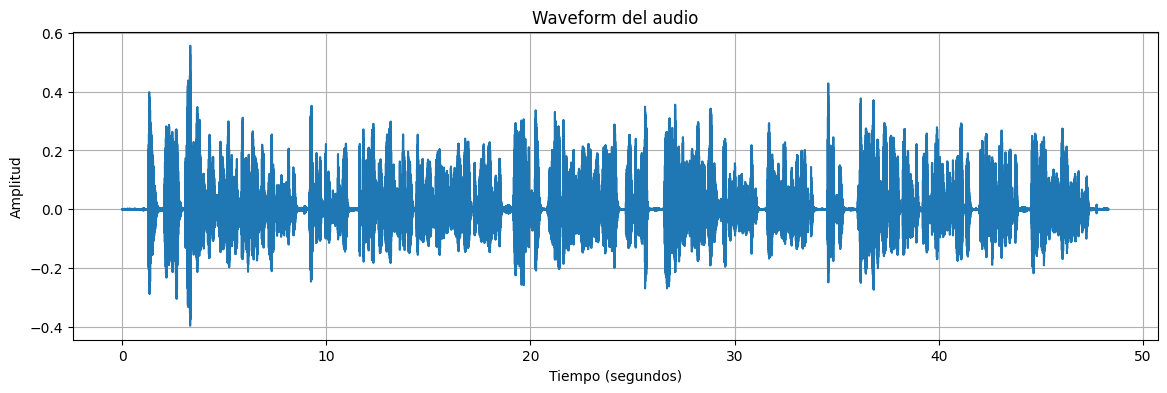

In [13]:
# --- 1. CONSTRUCCIÓN DEL EJE TEMPORAL (EJE X) ---
# Usamos np.linspace para crear un vector linealmente espaciado.
# - Inicio: 0 segundos.
# - Fin: La duración total del audio (total de muestras dividida entre el sample rate).
# - num=len(y): Aseguramos que este eje tenga exactamente la misma cantidad de puntos
#   que nuestro arreglo de audio, permitiendo un mapeo 1:1 perfecto.
tiempo = np.linspace(0, len(y) / sr, num=len(y))

# --- 2. CONFIGURACIÓN DEL LIENZO Y RENDERIZADO ---
# Definimos un lienzo ancho (14 pulgadas) y bajo (4 pulgadas) ideal para series de tiempo largas.
plt.figure(figsize=(14, 4))

# Graficamos el tiempo en las abscisas (X) y los valores de voltaje/presión sonora en las ordenadas (Y).
plt.plot(tiempo, y)

# --- 3. METADATOS GRÁFICOS Y ESTILIZADO ---
plt.title("Waveform del audio")
plt.xlabel("Tiempo (segundos)")

# La amplitud representa la presión del aire normalizada. Al haber usado librosa,
# los valores oscilarán estrictamente en un rango de [-1.0, 1.0].
plt.ylabel("Amplitud")

# Activamos la cuadrícula de fondo para facilitar la medición visual de eventos sonoros.
plt.grid(True)

# Renderizamos el gráfico final limpiando la memoria del buffer de matplotlib.
plt.show()

## ACTIVIDAD 6:

ESPECTROGRAMA LOG-MEL

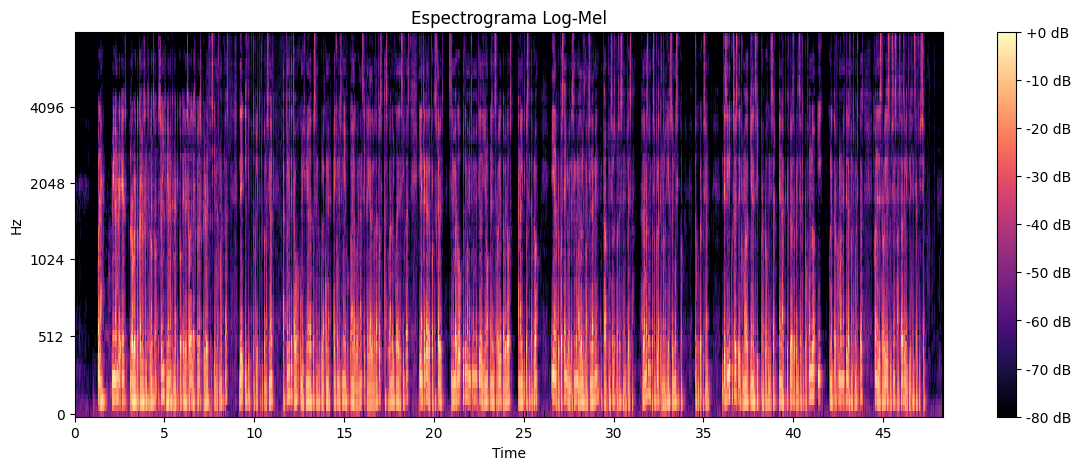

In [14]:
# --- 1. EXTRACCIÓN DE CARACTERÍSTICAS: ESPECTROGRAMA DE MEL ---
# Transformamos la señal aplicando la STFT (Transformada Corta de Fourier) y mapeando a la escala Mel.
mel_spec = librosa.feature.melspectrogram(
    y=y,
    sr=sr,
    n_mels=80,      # Número de bandas de frecuencia en la escala Mel (la resolución vertical). 80 es el estándar de Whisper.
    n_fft=400,      # Tamaño de la ventana de análisis en muestras (400 muestras a 16kHz equivalen a ventanas de 25 milisegundos).
    hop_length=160  # Distancia de desplazamiento entre ventanas (160 muestras equivalen a un paso de 10 milisegundos, 60% de solapamiento).
)

# --- 2. COMPRESIÓN DE RANGO DINÁMICO (ESCALA LOGARÍTMICA) ---
# El oído humano percibe la intensidad del sonido de forma logarítmica, no lineal.
# Convertimos la potencia de la señal a decibelios (dB).
# 'ref=np.max' establece el sonido más fuerte de la grabación como el punto de referencia de 0 dB (todo lo demás será negativo).
log_mel_spec = librosa.power_to_db(
    mel_spec,
    ref=np.max
)

# --- 3. CONFIGURACIÓN DEL LIENZO Y VISUALIZACIÓN ---
plt.figure(figsize=(14, 5))

# Función especializada de librosa para renderizar matrices de audio bidimensionales.
librosa.display.specshow(
    log_mel_spec,
    sr=sr,
    hop_length=160, # Debe coincidir exactamente con el hop_length usado al calcular el espectrograma.
    x_axis="time",   # Configura el eje horizontal automáticamente en segundos.
    y_axis="mel"     # Configura el eje vertical en la escala Mel (comprime frecuencias altas donde el oído humano es menos sensible).
)

# --- 4. ELEMENTOS INTERPRETATIVOS ---
# Agregamos la barra de color lateral para saber a qué decibelios corresponde cada color (Intensidad / Energía).
plt.colorbar(format="%+2.0f dB")
plt.title("Espectrograma Log-Mel")

# Renderizamos la "imagen" del sonido.
plt.show()

## ACTIVIDAD 7

**TRANSCRIPCIÓN CON WHISPER**

In [15]:
from transformers import WhisperProcessor, WhisperForConditionalGeneration
import torch

# --- 1. CONFIGURACIÓN E INICIALIZACIÓN DEL MODELO WHISPER ---
# "openai/whisper-base" es una versión balanceada de ~74 millones de parámetros,
# ideal para correr inferencias rápidas en entornos con recursos intermedios o GPUs estándar.
modelo_whisper = "openai/whisper-base"

# El Processor combina dos elementos en una sola clase: el Feature Extractor (que procesa el audio
# crudo y calcula el espectrograma Mel a 80 bandas) y el Tokenizer (que decodifica IDs de texto).
processor = WhisperProcessor.from_pretrained(modelo_whisper)

# Cargamos el modelo condicional generativo y lo enviamos al hardware acelerador (GPU/device).
model_whisper = WhisperForConditionalGeneration.from_pretrained(modelo_whisper).to(device)

# Activamos el modo de evaluación para garantizar estabilidad y optimizar el cómputo de atención.
model_whisper.eval()

# --- 2. PREPROCESAMIENTO DE LA SEÑAL ACÚSTICA ---
# El procesador toma el array de NumPy (y), valida que el sample rate sea el correcto (16kHz),
# extrae las características espectrales y las convierte en un tensor de PyTorch ("pt").
inputs = processor(
    y,
    sampling_rate=sr,
    return_tensors="pt"
)

# Whisper extrae los coeficientes Mel del audio y los guardamos en el dispositivo (VRAM/GPU).
input_features = inputs.input_features.to(device)

# --- 3. CONFIGURACIÓN DEL DECODIFICADOR (INYECCIÓN DE PROMPT) ---
# Forzamos al decodificador a arrancar con tokens específicos para guiar la generación.
# Le indicamos explícitamente que el idioma de origen es "spanish" y que la tarea
# es transcripción directa ("transcribe") en lugar de traducción ("translate").
forced_decoder_ids = processor.get_decoder_prompt_ids(
    language="spanish",
    task="transcribe"
)

# --- 4. INFERENCIA GENERATIVA AUTORREGRESIVA ---
# Desactivamos gradientes. El método .generate() ejecuta internamente un algoritmo de búsqueda
# (por defecto Beam Search) para encontrar la secuencia de texto más probable según el audio.
with torch.no_grad():
    predicted_ids = model_whisper.generate(
        input_features,
        forced_decoder_ids=forced_decoder_ids
    )

# --- 5. DECODIFICACIÓN TEXTUAL FINAL ---
# Tomamos los IDs de tokens predichos por el modelo y los convertimos en caracteres legibles.
# 'skip_special_tokens=True' elimina los tokens de control de Whisper (como <|startoftext|>, <|es|>, <|transcribe|>).
transcripcion = processor.batch_decode(
    predicted_ids,
    skip_special_tokens=True
)


preprocessor_config.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/290M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/245 [00:00<?, ?it/s]

generation_config.json: 0.00B [00:00, ?B/s]

Using custom `forced_decoder_ids` from the (generation) config. This is deprecated in favor of the `task` and `language` flags/config options.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> has been passed to `.generate()`, but it was also created in `.generate()`, given its parameterization. The custom <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> will take precedence. Please check the docstring of <class 'transformers.generation.logits_process.SuppressTokensLogitsProcessor'> to see related `.generate()` flags.
A custom logits processor of type <class 'transformers.generation.logits_process.SuppressTokensAtBeginLogitsProcessor'> has been passed to `.generate()`, 

In [16]:
# Mostramos el resultado del procesamiento en pantalla.
print("Transcripción:")
print(transcripcion[0])

Transcripción:
 Hola, mi nombre es Roberto Carlos Antesalonzo, soy ingenio matemático agresado de la Escuela Superior de Fisca y Matemáticas del Instituto Pilectecnico Nacional, actualmente trabajo como ingenio de datos en grupo la comer, ahí comencé muy enfocado en la gobernancia y calidad de los datos, asegurando el cuadre de cifras y la entrega de reportes claves, sin embargo últimamente me he metido de lleno en el desarrollo de tableros, analíticos en tablo y en la propuesta de implementación de modelos de Machine Learning para optimizarlo


### REFLEXIÓN 4

**¿Whisper transcribió correctamente tu audio?**
La mayor parte

**¿Qué errores cometió?**
A continuación pongo las palabras que puso mal:

| Palabra original (audio) | Palabra Whisper |
| --- | --- |
| Santos Alonzo | Antesalonzo |
| ingeniero | ingenio |
| egresado | agresado |
| Físicaca | Fisca |
| Politécnico | Pilectecnico |
| Tableau | Tablo |


# ACTIVIDAD 8

INYECCIÓN DE RUIDO BLANCO GAUSSIANO ---

In [17]:

# 1. Parámetro de Intensidad:
# Definimos la desviación estándar (Sgima) de nuestra distribución.
# Controla qué tan fuerte será el ruido inyectado en comparación con la señal original.
nivel_ruido = 0.02

# 2. Generación del Ruido Matemático:
# Usamos 'np.random.normal' para generar Ruido Blanco Gaussiano (AWGN).
# - 'loc=0.0': La media está centrada en cero para no introducir un desfase de corriente continua (DC offset).
# - 'scale=nivel_ruido': La desviación estándar determina la amplitud promedio del ruido.
# - 'size=len(y)': El vector de ruido debe tener exactamente las mismas dimensiones que el audio 'y'.
ruido = np.random.normal(
    loc=0.0,
    scale=nivel_ruido,
    size=len(y)
)

# 3. Superposición de Señales:
# Sumamos elemento a elemento la señal original y el vector de ruido.
# Físicamente, esto simula la interferencia acústica del entorno capturada por el micrófono.
y_ruidoso = y + ruido

# 4. Normalización Máxima (Prevención de Saturación):
# Al sumar el ruido, algunos picos de la señal podrían superar el rango permitido de [-1.0, 1.0].
# Dividimos todo el array por su valor absoluto máximo para escalar la señal perfectamente
# y evitar distorsión digital por truncamiento (clipping).
y_ruidoso = y_ruidoso / np.max(np.abs(y_ruidoso))

# --- RENDERIZADO DEL OUTPUT DE CONTROL ---
print("Audio con ruido:")
# Inyectamos el nuevo tensor ruidoso en el reproductor web para auditar el resultado auditivo.
display(Audio(y_ruidoso, rate=sr))

Audio con ruido:


# ACTIVIDAD 9:

TRANSCRIBIR AUDIO RUIDOSO

In [18]:
import torch

# --- 1. PREPROCESAMIENTO DE LA SEÑAL DEGRADADA ---
# El procesador extrae el espectrograma Log-Mel a partir de la señal con ruido.
# Aunque el audio contiene interferencia, la tasa de muestreo se mantiene fija (sr=16000 Hz).
# 'return_tensors="pt"' genera la estructura de datos compatible con PyTorch.
inputs_ruido = processor(
    y_ruidoso,
    sampling_rate=sr,
    return_tensors="pt"
)

# Movemos los coeficientes espectrales calculados a la memoria VRAM de la GPU (device).
input_features_ruido = inputs_ruido.input_features.to(device)

# --- 2. INFERENCIA CON CONDICIONAMIENTO DE ENTRADA ---
# Desactivamos el cálculo de gradientes (torch.no_grad) ya que estamos en fase de evaluación.
with torch.no_grad():
    # El decodificador vuelve a utilizar los mismos 'forced_decoder_ids' (idioma: español, tarea: transcribir)
    # que definimos previamente, garantizando que la única variable que cambia sea la calidad del audio.
    predicted_ids_ruido = model_whisper.generate(
        input_features_ruido,
        forced_decoder_ids=forced_decoder_ids
    )

# --- 3. DECODIFICACIÓN TEXTUAL DE LA SALIDA DEGRADADA ---
# Mapeamos los tokens generados por el modelo ruidoso de vuelta a texto plano.
# Volvemos a ignorar los tokens de control del sistema empleando 'skip_special_tokens=True'.
transcripcion_ruido = processor.batch_decode(
    predicted_ids_ruido,
    skip_special_tokens=True
)

# --- 4. ANÁLISIS COMPARATIVO DE ROBUSTEZ (MÉTRICA AUDITORÍA) ---
# Imprimimos la salida original (control) frente a la salida bajo estrés (experimento).
# Esto nos permite calcular visualmente la degradación de la tasa de error por palabra (WER - Word Error Rate).
print("Audio limpio:")
print(transcripcion[0])

print("\nAudio con ruido:")
print(transcripcion_ruido[0])

Audio limpio:
 Hola, mi nombre es Roberto Carlos Antesalonzo, soy ingenio matemático agresado de la Escuela Superior de Fisca y Matemáticas del Instituto Pilectecnico Nacional, actualmente trabajo como ingenio de datos en grupo la comer, ahí comencé muy enfocado en la gobernancia y calidad de los datos, asegurando el cuadre de cifras y la entrega de reportes claves, sin embargo últimamente me he metido de lleno en el desarrollo de tableros, analíticos en tablo y en la propuesta de implementación de modelos de Machine Learning para optimizarlo

Audio con ruido:
 Hola, mi nombre es Roberto Carlos Anticelonzo, soy un fulfill matemático el resultado de las colas primero de 6 kilomatemáticas del Instituto Piliensacional. Actualmente trabajas con el fulfill de datos en grupo de la Comencia, hay comenzamos y empezamos en la determinación, calidad de los datos, acerrando el poder de cifras y la entrega de reportes claros. Sin embargo, últimamente en el principio de lleno en el desarrollo de ta

### REFLEXIÓN 5

**¿Qué cambió entre la transcripción limpia y la ruidosa?**

Mi primer audio, no se escucha nada de fondo, es de alguna manera "limpio", ya que tiene la frecuencia de mi voz, si embargo cuando se añade ruido  incorpora interferencias externass que distorsionan el audio original.

El cambio que hubo entre el audio original y con ruido, es que con ruido genera frases que en ningún momento se comentaron.

**¿Por qué el ruido puede afectar a Whisper?**

Por que el fondo tiene un ruido constante, lo que hace que las capas del encoder no se concentren en los vectores de la voz, por consecuencia cuando le pasa la información al decoder, hace que este tenga una calidad mala.


# PARTE 4:
MINI VISION TRANSFORMER

En esta sección observarás cómo una imagen puede convertirse en una secuencia de patches.

In [19]:
# 1. Carga de Datos desde el Repositorio Canónico:
# .load_data() descarga automáticamente el dataset y realiza un desempaquetado estructurado.
# Separa de manera estricta las imágenes de entrenamiento (X) y sus etiquetas correspondientes (y),
# de los datos de prueba independientes (test) para evitar el sesgo de datos (data leakage).
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# 2. Escalado de Características (Min-Max Normalization):
# Las imágenes originales vienen codificadas en formato de 8 bits (enteros de 0 a 255 por píxel).
# Dividir entre 255.0 convierte cada celda de la matriz en un número flotante en el rango [0.0, 1.0].
# Esto es crítico para que el descenso de gradiente converja más rápido y los pesos no exploten.
X_train = X_train / 255.0
X_test = X_test / 255.0

# --- AUDITORÍA DE DIMENSIONES (SHAPE COERCION) ---
# Imprimimos la topología de los arreglos para verificar la estructura de tensores.
print("Train:", X_train.shape)
print("Test:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train: (60000, 28, 28)
Test: (10000, 28, 28)


## ACTIVIDAD 11

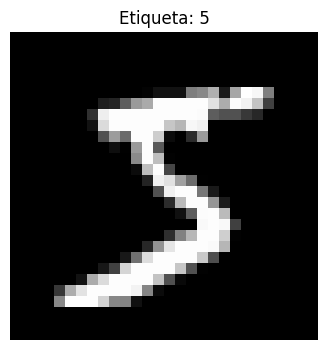

In [20]:
# --- ACTIVIDAD 11: RENDEREADO DE MATRICES NUMÉRICAS COMO IMÁGENES ---

# 1. Extracción de la Instancia de Control:
# Extraemos el primer elemento (índice 0) del tensor X_train.
# Este elemento es una matriz bidimensional de NumPy con dimensiones de 28x28.
imagen = X_train[0]

# 2. Inicialización del Contenedor Gráfico:
# Creamos un lienzo simétrico y compacto de 4x4 pulgadas, ideal para resoluciones bajas.
plt.figure(figsize=(4, 4))

# 3. Mapeo de Densidad de Píxeles (Renderizado):
# - 'imagen': La matriz de 28x28 flotantes entre 0.0 y 1.0.
# - cmap="gray": Forzamos el mapa de color a escala de grises. Los valores cercanos a 0.0
#   se pintarán negros (fondo) y los cercanos a 1.0 se pintarán blancos (el trazo del dígito).
plt.imshow(imagen, cmap="gray")

# 4. Inyección de Metadatos de Supervisión:
# Usamos un f-string para extraer dinámicamente el escalar correspondiente en y_train[0].
# Esto nos permite validar en el título de la gráfica el número real que la red debe aprender a predecir.
plt.title(f"Etiqueta: {y_train[0]}")

# 5. Optimización Estética del Canvas:
# Eliminamos los ejes cartesianos (ticks de coordenadas X e Y) ya que los valores de los índices
# de los píxeles (0-27) no aportan valor analítico a la visualización de la forma del dígito.
plt.axis("off")

# 6. Liberación del Buffer Gráfico:
# Desplegamos la imagen final limpiando la memoria caché de matplotlib.
plt.show()

## ACTIVIDAD 12

**DIVIDIR IMAGEN EN PATCHES**

In [21]:
# --- ACTIVIDAD 12: ESTRUCTURACIÓN DE PARCHES PARA VISION TRANSFORMERS (ViT) ---

# 1. Definición de la Granularidad Espacial:
# Establecemos el tamaño del parche (petición de 7x7 píxeles).
# Como la imagen es de 28x28, el tamaño de la imagen es perfectamente divisible entre 7 (28 / 7 = 4 parches por fila/columna).
patch_size = 7

# Estructura de almacenamiento lineal para la secuencia de parches
patches = []

# 2. Doble Bucle de Extracción Espacial (Mecanismo de Rebanado / Slicing):
# Recorremos la imagen en pasos de 7 en 7 píxeles tanto vertical (i) como horizontalmente (j).
for i in range(0, 28, patch_size):
    for j in range(0, 28, patch_size):
        # Extraemos una submatriz de 7x7 utilizando el operador de rebanado de NumPy.
        patch = imagen[i:i+patch_size, j:j+patch_size]

        # Agregamos el parche a nuestra lista, simulando el orden de lectura (de izquierda a derecha, de arriba a abajo).
        patches.append(patch)

# 3. Conversión a Tensor Estructurado:
# Transformamos la lista nativa de Python en un arreglo multidimensional de NumPy.
patches = np.array(patches)

# --- AUDITORÍA DE SALIDA DE LA TOPOLOGÍA ---
print("Número de patches:", len(patches))
print("Forma:", patches.shape)

Número de patches: 16
Forma: (16, 7, 7)


## ACTIVIDAD 13

**VISUALIZAR PATCHES**

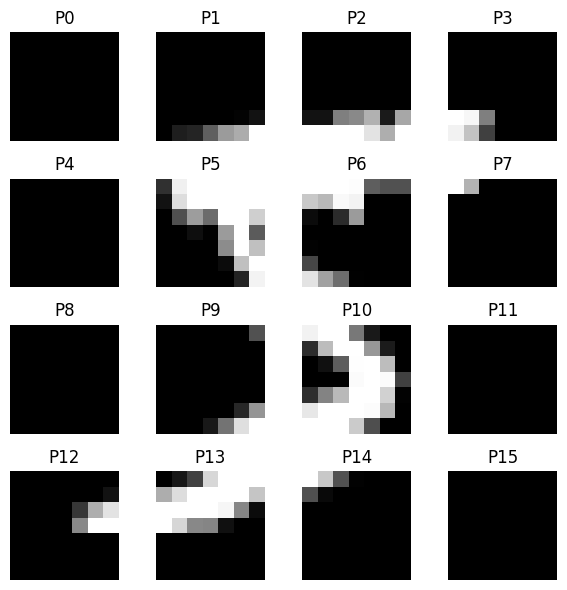

In [22]:
# --- CONFIGURACIÓN DE LA MATRIZ DE SUBGRÁFICAS ---
# Creamos una cuadrícula estricta de 4 filas por 4 columnas (un total de 16 ejes independientes).
# Definimos un lienzo cuadrado equilibrado de 6x6 pulgadas.
fig, axes = plt.subplots(4, 4, figsize=(6, 6))

# --- BUCLE DE RENDERIZADO SECUENCIAL ---
# .flat transforma la matriz bidimensional de objetos 'axes' (4x4) en un iterador lineal de 16 elementos.
# enumerate nos provee simultáneamente el índice secuencial (idx) y el contenedor del gráfico (ax).
for idx, ax in enumerate(axes.flat):
    # Pintamos el parche correspondiente utilizando la paleta de escala de grises.
    # Cada subgráfico recibe una matriz de dimensiones 7x7 píxeles.
    ax.imshow(patches[idx], cmap="gray")

    # Removemos las coordenadas cartesianas para priorizar la morfología visual del parche.
    ax.axis("off")

    # Etiquetamos cada sección con su ID de secuencia (P0, P1, ... P15).
    # Este índice numérico representa la posición temporal/espacial que el modelo debe aprender.
    ax.set_title(f"P{idx}")

# --- AJUSTE TOPOLÓGICO Y DESPLIEGUE ---
# 'tight_layout' reconfigura automáticamente las distancias y márgenes entre los subgráficos,
# evitando que las etiquetas de los títulos colisionen o se superpongan entre sí.
plt.tight_layout()

# Liberamos el buffer gráfico y proyectamos la descomposición molecular del dígito en pantalla.
plt.show()

## ACTIVIDAD 14
**FUNCIÓN PARA CREAR PATCHES EN TODO EL DATASET**

In [23]:
import numpy as np

# --- CONSTRUCCIÓN DE LA FUNCIÓN DE PROCESAMIENTO POR LOTES ---
def crear_patches(dataset, patch_size=7):
    # Contenedor principal que almacenará todo el dataset transformado
    imagenes_patches = []

    # Iteramos sobre cada una de las imágenes del conjunto (ej. las 5,000 de entrenamiento)
    for imagen in dataset:
        # Contenedor local para almacenar los 16 parches de la imagen actual
        patches = []

        # Doble bucle espacial para recorrer la imagen en bloques de 7x7 píxeles
        for i in range(0, 28, patch_size):
            for j in range(0, 28, patch_size):
                # 1. Extracción (Slicing) de la submatriz bidimensional de 7x7
                patch = imagen[i:i+patch_size, j:j+patch_size]

                # 2. Aplanado Lineal (Projection Input):
                # .flatten() convierte la matriz de 7x7 en un vector continuo de 49 elementos.
                # Este paso es indispensable porque las capas densas de atención matemática
                # requieren vectores vectorizados, no matrices espaciales.
                patch = patch.flatten()

                # Guardamos el vector del parche en la lista de la imagen actual
                patches.append(patch)

        # Añadimos la secuencia de parches terminada al lote general
        imagenes_patches.append(patches)

    # Convertimos la estructura de datos a un array nativo de NumPy para optimizar operaciones de tensores
    return np.array(imagenes_patches)

# --- EJECUCIÓN DEL PIPELINE Y REDUCCIÓN DE ESCALA (SUBSAMPLING) ---
# Aplicamos la función sobre los primeros 5,000 ejemplos de entrenamiento y 1,000 de prueba.
# Esto reduce el costo computacional (RAM/VRAM) y evita cuellos de botella en entornos locales.
X_train_patches = crear_patches(X_train[:5000])
X_test_patches = crear_patches(X_test[:1000])

# Ajustamos las etiquetas (targets) para que coincidan exactamente con los subconjuntos recortados.
y_train_small = y_train[:5000]
y_test_small = y_test[:1000]

# --- AUDITORÍA TOPOLÓGICA DE LOS NUEVOS TENSORES ---
print("Train patches:", X_train_patches.shape)
print("Test patches:", X_test_patches.shape)

Train patches: (5000, 16, 49)
Test patches: (1000, 16, 49)


## ACTIVIDAD 15

**MINI BLOQUE TRANSFORMER**

In [24]:
# --- DISEÑO DEL BLOQUE ENCODER TRANSFORMER ---
def transformer_block(x):

    # === SUB-CAPA 1: MECANISMO DE AUTO-ATENCIÓN MULTI-CABEZA ===
    # Instanciamos la capa de atención.
    # - num_heads=2: El modelo divide el espacio de representación en 2 subespacios independientes
    #   para buscar diferentes relaciones o patrones espaciales de forma paralela.
    # - key_dim=32: Dimensión del vector Query, Key y Value por cada una de las cabezas.
    # Al pasar (x, x), la matriz actúa como Query, Key y Value simultáneamente -> Auto-Atención.
    attention = MultiHeadAttention(
        num_heads=2,
        key_dim=32
    )(x, x)

    # --- Conexión Residual y Normalización 1 ---
    # Sumamos la entrada original 'x' al output de la atención. Esto previene la disipación
    # del gradiente (Vanishing Gradient) y permite que la información base fluya sin alterarse.
    x = x + attention
    # Estabilizamos los valores a nivel de lote y secuencia utilizando normalización de capa.
    x = LayerNormalization()(x)

    # === SUB-CAPA 2: RED NEURONAL FEED-FORWARD (MLP) ===
    # Procesamos cada token de forma independiente pero idéntica a través de una red densa.
    # - Dense(128): Capa de proyección intermedia que expande la dimensionalidad (Feature Extraction).
    ff = Dense(128, activation="relu")(x)
    # - Dense(64): Capa de contracción que devuelve el tensor a su forma original para la suma residual.
    # Nota: Si tu dimensión de entrada no es 64, esta capa debe ajustarse dinámicamente al tamaño de x.
    ff = Dense(64)(ff)

    # --- Conexión Residual y Normalización 2 ---
    # Volvemos a inyectar una conexión residual (x + ff) para mantener la estabilidad del gradiente.
    x = x + ff
    # Segunda normalización para preparar el tensor de salida hacia el siguiente bloque o capa densa final.
    x = LayerNormalization()(x)

    return x

## ACTIVIDAD 16

**CONSTRUIR MINI VIT**

In [25]:
# --- ACTIVIDAD 16: ENSAMBLADO DEFECTUOSO Y COMPILACIÓN DEL MINI ViT ---

# 1. Capa de Entrada (Input Layer):
# Definimos el punto de entrada de la red. Espera tensores bidimensionales con la forma (16, 49).
# Donde 16 es la longitud de la secuencia (número de parches) y 49 es el tamaño del parche aplanado (7x7).
inputs = Input(shape=(16, 49))

# 2. Proyección Lineal de Embeddings (Linear Projection):
# Transforma cada parche de 49 píxeles en un vector continuo de 64 dimensiones.
# Esto equivale a la capa lineal del ViT original que mapea los parches al espacio latente del Transformer.
x = Dense(64)(inputs)

# 3. Procesamiento de Contexto Secuencial:
# Inyectamos la matriz proyectada en nuestro bloque Transformer.
# Aquí los 16 parches se comunicarán entre sí mediante auto-atención multi-cabeza para capturar la estructura del dígito.
x = transformer_block(x)

# 4. Reducción de la Dimensión Temporal/Secuencial (Aggregation Layer):
# GlobalAveragePooling1D toma el promedio de los embeddings a lo largo del eje de la secuencia (las 16 posiciones).
# Reduce el tensor de una forma bidimensional (16, 64) a un vector plano unidimensional de (64,).
# Actúa como una alternativa eficiente al token de clasificación [CLS] usado en el ViT original.
x = GlobalAveragePooling1D()(x)

# 5. Cabeza del Clasificador (Classification Head - MLP):
# - Capa densa intermedia de 64 neuronas con activación ReLU para introducir no-linealidades.
x = Dense(64, activation="relu")(x)
# - Regularización por Dropout: Apaga aleatoriamente el 20% de las neuronas en cada paso de entrenamiento
#   para prevenir el sobreajuste (overfitting) y forzar a la red a aprender representaciones robustas.
x = Dropout(0.2)(x)

# 6. Capa de Salida (Output Layer):
# Genera un vector de 10 neuronas (una por cada dígito del 0 al 9).
# La activación Softmax convierte los puntajes brutos (logits) en una distribución de probabilidad que suma 1.0.
outputs = Dense(10, activation="softmax")(x)

# --- INSTANCIACIÓN DEL GRAFO DE CÓMPUTO ---
# Vinculamos la capa de entrada con la de salida para compilar la topología del modelo estructural.
modelo_vit = Model(inputs, outputs)

# --- CONFIGURACIÓN DEL PROCESO DE OPTIMIZACIÓN ---
modelo_vit.compile(
    # Usamos el optimizador Adam con una tasa de aprendizaje (learning rate) estándar de 0.001.
    optimizer=Adam(0.001),
    # Elegimos Sparse Categorical Crossentropy porque nuestras etiquetas (y_train_small) son
    # números enteros (escalares del 0 al 9), evitando la necesidad de aplicar codificación One-Hot encode.
    loss="sparse_categorical_crossentropy",
    # Monitoreamos la precisión (Accuracy) como métrica de rendimiento para el negocio o reporte de IA.
    metrics=["accuracy"]
)

# --- INFORME DE ARQUITECTURA DE CAPAS ---
# Desiega en la consola el desglose completo del modelo: tipos de capas, formas de los tensores de salida
# en cada paso y el conteo de parámetros entrenables.
modelo_vit.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 16, 49)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 16, 64)    │      3,200 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 16, 64)    │     16,640 │ dense[0][0],      │
│ (MultiHeadAttentio… │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 16, 64)    │          0 │ dense[0][0],      │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 16, 64)    │        128 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 16, 128)   │      8,320 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16, 64)    │      8,256 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 16, 64)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 16, 64)    │        128 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ layer_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      4,160 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64)        │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 10)        │        650 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 41,482 (162.04 KB)

 Trainable params: 41,482 (162.04 KB)

 Non-trainable params: 0 (0.00 B)

# ACTIVIDAD 17
**ENTRENAR MINI VIT**

> Aumento de $5$ épocas a $200$. Lo realice con GPU (algo que nos enseñaron en el modulo de CNN)



In [26]:
# --- FASE DE ENTRENAMIENTO Y AJUSTE DE PESOS DEL MINI ViT ---

# Almacenamos el resultado de la iteración en la variable 'historial'.
# Este objeto guardará las métricas (loss y accuracy) de cada época para poder graficarlas después.
historial = modelo_vit.fit(
    # 1. Tensores de Entrada (X): Los 16 parches aplanados (de 49 valores cada uno) por imagen.
    X_train_patches,

    # 2. Etiquetas Objetivo (Y): Los valores reales (enteros del 0 al 9) de cada dígito manuscrito.
    y_train_small,

    # 3. Validación Cruzada Automática (Validation Split):
    # Separamos el 20% de las 5,000 muestras (es decir, 1,000 imágenes) como conjunto de control.
    # El modelo NO se entrena con estas imágenes; solo las usa al final de cada época para
    # evaluar si está generalizando bien o si está cayendo en sobreajuste (overfitting).
    validation_split=0.2,

    # 4. Ciclos de Aprendizaje (Epochs):
    # El modelo recorrerá el conjunto de entrenamiento completo exactamente 5 veces.
    epochs=200,

    # 5. Tamaño del Lote (Batch Size):
    # Procesamos 128 imágenes en paralelo antes de realizar la actualización de los pesos de la red.
    # Un tamaño de lote de 128 optimiza el paralelismo en la GPU sin saturar la memoria RAM.
    batch_size=128
)

Epoch 1/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 42s 743ms/step - accuracy: 0.2652 - loss: 2.0831 - val_accuracy: 0.4700 - val_loss: 1.7143
Epoch 2/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4482 - loss: 1.6522 - val_accuracy: 0.5310 - val_loss: 1.4336
Epoch 3/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5077 - loss: 1.4620 - val_accuracy: 0.5600 - val_loss: 1.3087
Epoch 4/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5543 - loss: 1.3260 - val_accuracy: 0.6000 - val_loss: 1.1992
Epoch 5/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5972 - loss: 1.1898 - val_accuracy: 0.6170 - val_loss: 1.1442
Epoch 6/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6357 - loss: 1.0887 - val_accuracy: 0.6400 - val_loss: 1.0776
Epoch 7/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6570 - loss: 1.0188 - val_accuracy: 0.6760 - val_loss: 1.0078
Epoch 8/200
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6895 - loss: 0.9333 - val_accuracy: 0.6840 

## ACTIVIDAD 18

**EVALUAR MINI VIT**

In [28]:
# --- ACTIVIDAD 18: EVALUACIÓN SÓLIDA DE GENERALIZACIÓN ---

# Ejecutamos el método .evaluate() sobre el dataset de prueba (test set).
# El modelo realiza un forward pass (pasada hacia adelante) con las 1,000 imágenes de prueba,
# calcula el error y la precisión promedio, pero SIN actualizar los pesos (los gradientes están desactivados).
loss, acc = modelo_vit.evaluate(
    # 1. Tensores de Entrada Independientes: Secuencias de parches de prueba.
    X_test_patches,

    # 2. Etiquetas de Control Real: Los dígitos correctos correspondientes a esas imágenes.
    y_test_small
)

# --- REPORTE DE MÉTRICAS DE PRODUCCIÓN ---
# Imprimimos la precisión final (Accuracy), que representa la fracción de imágenes de prueba
# que el modelo logró clasificar con éxito (valores entre 0.0 y 1.0).
print("Accuracy:", acc)

32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 176ms/step - accuracy: 0.8070 - loss: 1.0594
Accuracy: 0.8069999814033508


## ACTIVIDAD 19:

**CURVAS DE ENTRENAMIENTO**

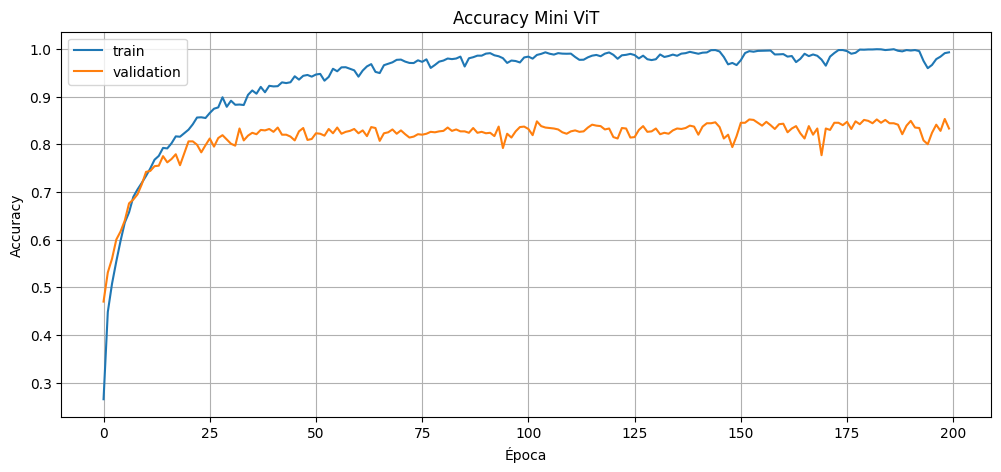

In [29]:
# --- ACTIVIDAD 19: RENDEREADO DE DIAGNÓSTICO METROLÓGICO (CURVAS DE APRENDIZAJE) ---

# 1. Configuración del Lienzo Panorámico:
# Establecemos un ancho de 12 pulgadas y alto de 5, ideal para observar la pendiente y suavidad de las líneas.
plt.figure(figsize=(12, 5))

# 2. Mapeo de Trayectorias de Rendimiento:
# - 'historial.history["accuracy"]': Extrae los aciertos en los datos con los que el modelo ajustó sus pesos.
plt.plot(historial.history["accuracy"], label="train")
# - 'historial.history["val_accuracy"]': Extrae los aciertos en el 20% de datos de control ocultos.
plt.plot(historial.history["val_accuracy"], label="validation")

# 3. Enriquecimiento de Metadatos del Gráfico:
plt.title("Accuracy Mini ViT")
plt.xlabel("Época")
plt.ylabel("Accuracy")

# 4. Inyección de Elementos de Control Visual:
# - .legend(): Coloca el cuadro indicativo para distinguir la línea de entrenamiento de la de validación.
plt.legend()
# - .grid(True): Habilita la cuadrícula estricta para leer con precisión el valor numérico de cada época.
plt.grid(True)

# 5. Despliegue y Liberación de Memoria del Buffer:
plt.show()

### REFLEXIÓN 6

**¿Qué representa un patch?**

Es la forma de "tokenizar" una imagen, recordar que el Transofrmer fueron diseñados para secuencias de texto.

**¿Por qué un Vision Transformer necesita positional encoding?**

Sino utilizaramos el **positional encoding**, el modelo pierde por completo la estructura espacial de la imagen, un ejemplo que se menciono en clase es: "esta bien reconocer que la nariz va debajo de los ojos, pero no esta bien ver los ojos debajo de la nariz".


**¿Por qué ViT suele requerir más datos que una CNN?**

Las CNNs tienen la ventaja que "saben" descomponer la imagen por experiencia humanda, con estas redes, descompones la imagen por kernels lo cual ya le da la ventaja a la red de que estos están relacionados entre sí. Sin embargo, los VIT arrancan aprenden desde $0$, no sabe nada sobre la estructura de las imágenes, por esto es que tiene que tener más datos para aprender.



# Conclusión final

Responde:

1. **¿Qué tienen en común BERT, Whisper y ViT?**

Que se basan en la arquitectura del **Transofrmer**, además recordar que utilizan:


*   Tokenización
*   Position encoding

2. **¿Qué cambia entre texto, audio e imagen?**

La diferencia radica en que:


*   El texto es discreto y unidimensional.
*   El audio es continuo y tiene tempralidad.
*   La imagen es continua y bidimensional

3. **¿Qué modelo te pareció más interesante y por qué?**

Me gustó más el modelo de **BERT**, sobre todo como de ahí surgen los modelos como **RoBERTa**, **DistilBERT** y **BETO**

4. **Propón una aplicación real usando Transformers.**

Para mí proyecto final, tengo en mente poder resolver un tema que radica en grupo La Comer. Actualmente los comentarios que hacen en la página se analizan de manera manual y una ves etiquetados los comentarios, se mandan al departamento correspondiente. Quisiera realizar un modelo de clasificación y aplicar un modelo encoder - decoder cuando los comentarios son muy largos.



